In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openrouter import ChatOpenRouter
from typing import TypedDict
from dotenv import load_dotenv

C:\Users\user pc\PycharmProjects\LangGraph_Practice\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenRouter(
    model="inclusionai/ling-3.0-flash-vl:free",
    temperature=0
)

In [4]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:
    title = state["title"]

    prompt = f"Generate a detailed outline for a blog on the topic - {title}"
    outline = model.invoke(prompt).content

    state["outline"] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:
    title = state["title"]
    outline = state["outline"]

    prompt = f"Write a detailed blog on the title - {title} using the following \n {outline}"

    content = model.invoke(prompt).content

    state["content"] = content

    return state

In [7]:
graph = StateGraph(BlogState)

graph.add_node("create_outline", create_outline)
graph.add_node("create_blog", create_blog)

graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_blog")
graph.add_edge("create_blog", END)

workflow = graph.compile()

In [8]:
initial_state = {"title": "Rise of AI in Africa"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in Africa', 'outline': '# Blog Outline: *The Rise of AI in Africa — How the Continent Is Shaping the Future of Technology*\n\n---\n\n## I. Introduction\n   - **Hook:** A compelling opening statistic or anecdote (e.g., "By 2030, AI could contribute up to $15.7 trillion to the global economy — and Africa is poised to claim a significant share.")\n   - **Context Setting:** Brief overview of the global AI boom and why Africa\'s role is often overlooked yet increasingly significant.\n   - **Thesis Statement:** Africa is no longer a passive consumer of technology — it is becoming an active innovator, adopter, and shaper of artificial intelligence.\n   - **Scope of the Blog:** What readers will learn (current landscape, key sectors, challenges, opportunities, future outlook).\n\n---\n\n## II. Setting the Stage — Africa\'s Technology Journey\n   - **Historical Context:**\n     - Africa\'s leap from minimal internet connectivity to mobile-first digital economies (e.g., M-P

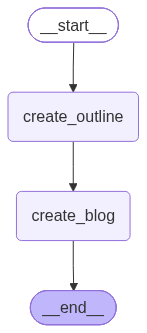

In [10]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png(
))